The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


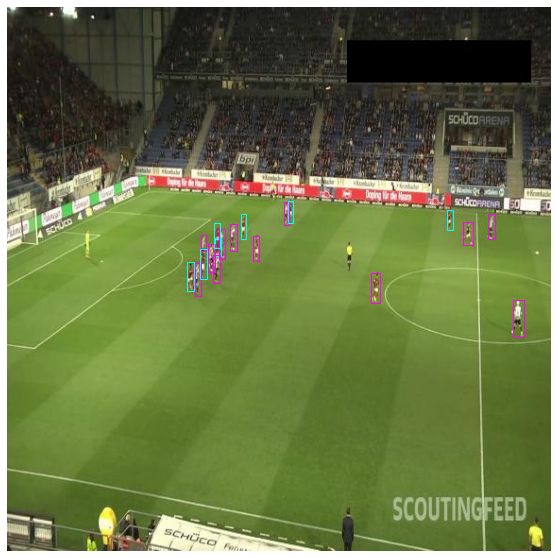

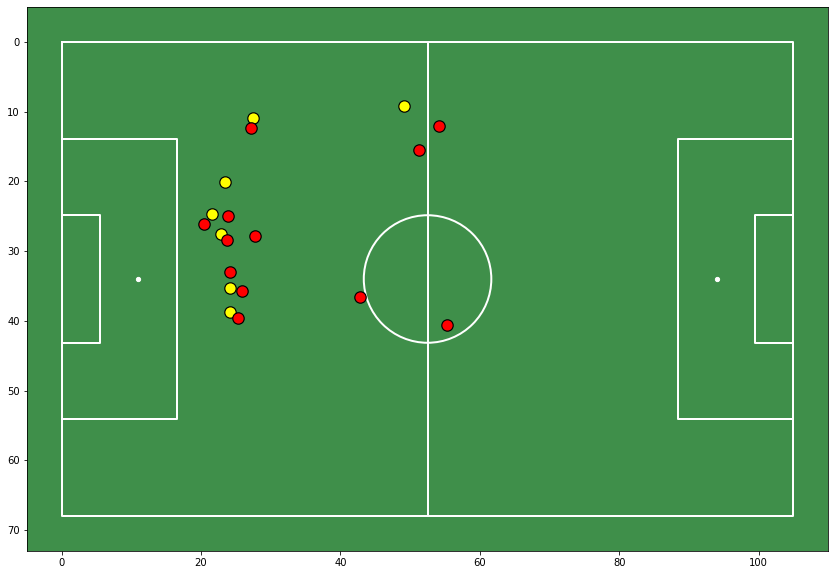

In [33]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

from src.viz import dibujarCampo, dibujarCajas, dibujarPuntosCenital
from src.CocoDataset import CocoDataset
from src.geometria import puntoApoyo,calcularHomografia, aMetros
from src.pipeline import analizarImagen
from src.campo import separarPorCampo
import matplotlib.pyplot as plt

CORRESPONDENCIAS = [
    ((215, 228), (16.5, 13.84)),
    (( 30, 361), (16.5, 54.16)),
    ((498, 220), (52.5,  0.00)),
    ((499, 278), (52.5, 24.85)),
    ((504, 360), (52.5, 43.15)),
]

ds = CocoDataset("../data/raw/football-players/valid")
IMG_ID = 41

img = ds.imagen(IMG_ID)

cajas = [c for c, k in ds.cajas(IMG_ID) if k == "player"]

pares = analizarImagen(ds, IMG_ID, cajas)

puntos = []

for caja in cajas:
    puntos.append(puntoApoyo(caja))

H, Hinv = calcularHomografia(CORRESPONDENCIAS)
equipos = [e for _, e in pares]
metros = aMetros(H, puntos) 
dentro, fuera = separarPorCampo(metros)

m0 = [m for m, e in zip(metros, equipos) if e == "e0"]
m1 = [m for m, e in zip(metros, equipos) if e == "e1"]

fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(ds.imagen(IMG_ID))
ax.axis("off")
dibujarCajas(ax, pares, colores={"e0": "cyan", "e1": "magenta"})
plt.show()

fig, ax = plt.subplots(figsize=(15, 10))
dibujarCampo(ax)
dibujarPuntosCenital(ax, m0)
dibujarPuntosCenital(ax, m1, color="red")
plt.show()

In [34]:
from src.modelo import crearModelo
import torch

modelo = crearModelo(congelarBackbone=False,ligero=False)
modelo.load_state_dict(torch.load("../outputs/modelo_experimento_ResNet_20ep.pt", map_location=torch.device('cpu')))
modelo.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

23 detectados -> 22 en el campo | e0: 6  e1: 16


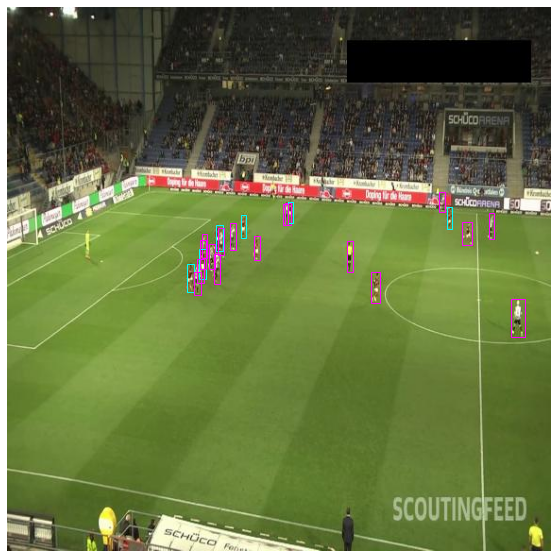

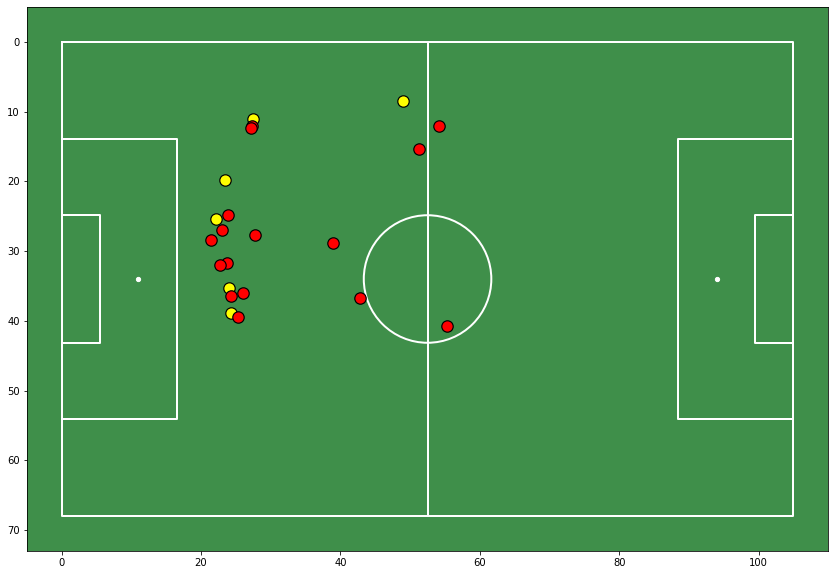

In [41]:
from torchvision.transforms.functional import to_tensor
from src.campo import enCampo

PERSONAS = {3}
UMBRAL   = 0.50

x = to_tensor(ds.imagen(IMG_ID))

with torch.no_grad():
    pred = modelo([x])[0]

cajas = [
    b for b, l, s in zip(pred["boxes"].tolist(),
                         pred["labels"].tolist(),
                         pred["scores"].tolist())
    if int(l) in PERSONAS and s >= UMBRAL
]

pares = analizarImagen(ds, IMG_ID, cajas)

puntos  = [puntoApoyo(c) for c, _ in pares]
equipos = [e for _, e in pares]
metros  = aMetros(H, puntos)

juntos = [(m, e) for m, e in zip(metros, equipos) if enCampo(m)]

m0 = [m for m, e in juntos if e == "e0"]
m1 = [m for m, e in juntos if e == "e1"]

print(len(metros), "detectados ->", len(juntos), "en el campo",
      f"| e0: {len(m0)}  e1: {len(m1)}")

fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(ds.imagen(IMG_ID))
ax.axis("off")
dibujarCajas(ax, pares, colores={"e0": "cyan", "e1": "magenta"})
plt.show()

fig, ax = plt.subplots(figsize=(15, 10))
dibujarCampo(ax)
dibujarPuntosCenital(ax, m0)
dibujarPuntosCenital(ax, m1, color="red")
plt.show()